In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import numpy as np
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt

from jax import random, jit, value_and_grad
from jax import config
from scipy.optimize import minimize

config.update("jax_enable_x64", True)
%matplotlib inline

In [3]:
def func(x):
    """Latent function."""
    return 1.0 * jnp.sin(x * 3 * jnp.pi) + \
           0.3 * jnp.cos(x * 9 * jnp.pi) + \
           0.5 * jnp.sin(x * 7 * jnp.pi)


# Number of training examples
n = 250

# Noise
sigma_y = 0.2

# Noisy training data
X = jnp.linspace(-1.0, 1.0, n).reshape(-1, 1)
y = func(X) + sigma_y * random.normal(random.PRNGKey(0), shape=(n, 1))

# Test data
X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
f_true = func(X_test)

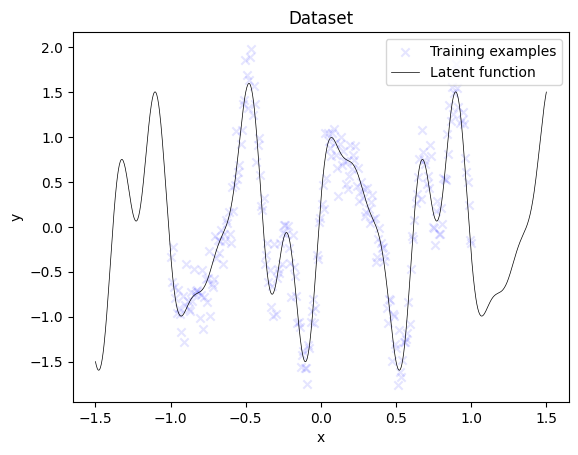

In [4]:
plt.scatter(X, y, label='Training examples', marker='x', color='blue', alpha=0.1)
plt.plot(X_test, f_true, label='Latent function', c='k', lw=0.5)
plt.title('Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend();

In [63]:
params = {
    "kernel":
    {
        "coefficient": jnp.array(0.9,dtype=jnp.float64),
        "log_scale":jnp.array(0.,dtype=jnp.float64)
    },
    "mean":{},
    "likelihood": 
    {
        "log_diag":jnp.array(-0.5,dtype=jnp.float64)
    }
}

In [64]:
def softplus(X):
    return jnp.log(1 + jnp.exp(X))

In [67]:
kernel = gp.kernel(**params["kernel"])
mean = gp.mean(**params["mean"])

log_noise = params["likelihood"]["log_diag"]
noise = softplus(log_noise)
sq_noise = jnp.square(noise)

covariance = kernel(X, X) + sq_noise
L_xx = jnp.linalg.cholesky(covariance)

alpha = jsp.linalg.cho_solve((L_xx, True), y)
S2 = jsp.linalg.cho_solve((L_xx.T, False), alpha)

In [53]:
log_likelihood = -0.5 * jnp.dot(y.T, S2)
log_likelihood -= jnp.log(jnp.diag(L_xx)).sum()
log_likelihood -= 0.5 * gp.num_data * jnp.log(2.0 * jnp.pi)

In [77]:
eig, _ = jnp.linalg.eig(covariance + 1e-1*jnp.eye(X.shape[0]))

In [78]:
eig

Array([1.99907898e+02+0.00000000e+00j, 6.12539563e+01+0.00000000e+00j,
       1.70701057e+01+0.00000000e+00j, 2.91901627e+00+0.00000000e+00j,
       4.92932232e-01+0.00000000e+00j, 1.39444393e-01+0.00000000e+00j,
       1.03614949e-01+0.00000000e+00j, 1.00260376e-01+0.00000000e+00j,
       1.00017754e-01+0.00000000e+00j, 1.00000998e-01+0.00000000e+00j,
       1.00000054e-01+0.00000000e+00j, 1.00000002e-01+0.00000000e+00j,
       1.00000000e-01+0.00000000e+00j, 1.00000000e-01+0.00000000e+00j,
       1.00000000e-01+0.00000000e+00j, 1.00000000e-01+0.00000000e+00j,
       1.00000000e-01+6.13485448e-15j, 1.00000000e-01-6.13485448e-15j,
       1.00000000e-01+4.82827823e-15j, 1.00000000e-01-4.82827823e-15j,
       1.00000000e-01+1.50569260e-15j, 1.00000000e-01-1.50569260e-15j,
       1.00000000e-01+7.01788107e-15j, 1.00000000e-01-7.01788107e-15j,
       1.00000000e-01+6.19801616e-15j, 1.00000000e-01-6.19801616e-15j,
       1.00000000e-01+0.00000000e+00j, 1.00000000e-01+3.33182066e-15j,
      

In [34]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared

In [35]:
from jax_mc_pilco.model_learning.gp.gaussian_process import gp_fit, GaussianProcess

In [51]:
gp = GaussianProcess(ExpSquared,X,y,params)

In [52]:
gp = gp_fit(gp)

TypeError: Gradient only defined for scalar-output functions. Output had shape: (1,).

In [31]:
gp.params

{'kernel': {'coefficient': Array(nan, dtype=float64),
  'log_scale': Array(nan, dtype=float64)},
 'likelihood': {'log_diag': Array(nan, dtype=float64)},
 'mean': {}}

In [30]:
gp.predict(X_test)

TypeError: Error interpreting argument to <function GaussianProcess.predict at 0x129eb5ee0> as an abstract array. The problematic value is of type <class 'equinox._module._module._ModuleMeta'> and was passed to the function at path self.kernel.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.